# IsoCLIP on Kaggle with CUB-200-2011

This notebook reproduces the main IsoCLIP pipeline on the CUB-200-2011 dataset:

1. Prepare the Kaggle environment and IsoCLIP source code.
2. Download CUB-200-2011 from Caltech Data and place it under the correct `--dataroot`.
3. Validate the project `cub2011` dataset loader.
4. Run image-to-image retrieval with the CLIP baseline.
5. Run image-to-image retrieval with IsoCLIP.
6. Read `summary.csv` and compare the metrics.

GPU and Internet access are recommended in Kaggle Notebook Settings.

## 0. General Configuration

The project loader expects the CUB dataset in this layout:

```text
/kaggle/working/datasets/CUB_200_2011/
+-- images.txt
+-- image_class_labels.txt
+-- train_test_split.txt
+-- images/
```

`DATA_ROOT` points to `/kaggle/working/datasets`, and the project dataset name is `cub2011`.

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import shutil

IS_KAGGLE = Path('/kaggle/working').exists()
WORK_DIR = Path('/kaggle/working') if IS_KAGGLE else Path.cwd()
DATA_ROOT = WORK_DIR / 'datasets'
CUB_DIR = DATA_ROOT / 'CUB_200_2011'

DATASET_NAME = 'cub2011'
CLIP_MODEL_NAME = 'ViT-B/32'
ISO_KTOP = 150
ISO_KBOTTOM = 50
RUN_BASELINE = True
RUN_ISOCLIP = True
FORCE_CPU_RETRIEVAL = False
AUTO_CPU_FALLBACK_FOR_INCOMPATIBLE_GPU = True

DATA_ROOT.mkdir(parents=True, exist_ok=True)

print('WORK_DIR:', WORK_DIR)
print('DATA_ROOT:', DATA_ROOT)
print('CUB_DIR:', CUB_DIR)
print('CLIP_MODEL_NAME:', CLIP_MODEL_NAME)
print('FORCE_CPU_RETRIEVAL:', FORCE_CPU_RETRIEVAL)

WORK_DIR: /kaggle/working
DATA_ROOT: /kaggle/working/datasets
CUB_DIR: /kaggle/working/datasets/CUB_200_2011
CLIP_MODEL_NAME: ViT-B/32
FORCE_CPU_RETRIEVAL: False


## 1. Prepare the IsoCLIP Source Code

If this notebook is already inside this repository, it uses the current repository. If the notebook is run standalone on Kaggle, this cell clones `https://github.com/toanthangO20/IsoCLIP_ImageRetrieval` into `/kaggle/working/IsoCLIP_ImageRetrieval`.

In [2]:
def run(cmd, cwd=None, check=True, env=None):
    cmd = [str(x) for x in cmd]
    print('> ' + ' '.join(cmd))
    return subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=check, env=env)

candidate_dirs = [Path.cwd(), WORK_DIR / 'IsoCLIP_ImageRetrieval']
PROJECT_DIR = None

for candidate in candidate_dirs:
    if (candidate / 'src' / 'retrieval.py').exists():
        PROJECT_DIR = candidate.resolve()
        break

if PROJECT_DIR is None:
    PROJECT_DIR = WORK_DIR / 'IsoCLIP_ImageRetrieval'
    if not PROJECT_DIR.exists():
        run(['git', 'clone', 'https://github.com/toanthangO20/IsoCLIP_ImageRetrieval.git', str(PROJECT_DIR)])

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / 'src'))

print('PROJECT_DIR:', PROJECT_DIR)
print('Current directory:', Path.cwd())

> git clone https://github.com/toanthangO20/IsoCLIP_ImageRetrieval.git /kaggle/working/IsoCLIP_ImageRetrieval


Cloning into '/kaggle/working/IsoCLIP_ImageRetrieval'...


PROJECT_DIR: /kaggle/working/IsoCLIP_ImageRetrieval
Current directory: /kaggle/working/IsoCLIP_ImageRetrieval


## 2. Install Dependencies

This cell installs the packages required for the CUB retrieval pipeline: Dassl, OpenAI CLIP, OpenCLIP, TorchMetrics, and auxiliary dependencies. Kaggle already ships with PyTorch and core packages such as `numpy`, `pandas`, `scikit-learn`, and `tqdm`, so this notebook does not downgrade them in order to avoid conflicts with the Kaggle environment.

In [3]:
def import_ok(module_name):
    try:
        module = __import__(module_name)
        print(f'{module_name}:', getattr(module, '__version__', 'import ok'))
        return True
    except Exception as exc:
        print(f'{module_name} import failed: {type(exc).__name__}: {exc}')
        return False

if not (import_ok('numpy') and import_ok('scipy')):
    print('Repairing NumPy/SciPy binary stack for the current Kaggle image...')
    run([
        sys.executable, '-m', 'pip', 'install', '-q',
        '--force-reinstall', '--no-cache-dir',
        'numpy>=2.0,<2.3',
        'scipy>=1.14,<1.16',
    ])
    raise SystemExit('NumPy/SciPy were reinstalled. Restart the Kaggle session/kernel, then run the notebook again from the first cell.')

# Kaggle ships with recent numpy/pandas/sklearn/tqdm. Do not downgrade them:
# downgrading these core packages triggers many resolver conflict warnings and can break
# unrelated Kaggle packages. The CUB retrieval pipeline only needs the packages below.
base_packages = [
    'wheel',
    'PyYAML>=6.0.3,<6.1',
    'dotmap==1.3.30',
    'torchmetrics==1.4.0.post0',
    'openpyxl==3.1.2',
    'tabulate==0.9.0',
    'gdown==5.2.0',
    'easydict==1.13',
    'yacs==0.1.8',
    'ftfy',
    'regex',
    'timm',
    'open-clip-torch==3.2.0',
]

run([sys.executable, '-m', 'pip', 'install', '-q'] + base_packages)
run([sys.executable, '-m', 'pip', 'install', '-q', '--no-build-isolation', 'git+https://github.com/KaiyangZhou/Dassl.pytorch'])

clip_specs = [
    'git+https://github.com/openai/CLIP.git@jongwook/issue-396',
    'git+https://github.com/openai/CLIP.git',
]

for spec in clip_specs:
    try:
        run([sys.executable, '-m', 'pip', 'install', '-q', '--no-build-isolation', spec])
        print('Installed CLIP from:', spec)
        break
    except subprocess.CalledProcessError:
        print('CLIP install failed for:', spec)
else:
    raise RuntimeError('Could not install OpenAI CLIP')

numpy: 2.0.2
scipy: 1.16.3
> /usr/bin/python3 -m pip install -q wheel PyYAML>=6.0.3,<6.1 dotmap==1.3.30 torchmetrics==1.4.0.post0 openpyxl==3.1.2 tabulate==0.9.0 gdown==5.2.0 easydict==1.13 yacs==0.1.8 ftfy regex timm open-clip-torch==3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
> /usr/bin/python3 -m pip install -q --no-build-isolation git+https://github.com/KaiyangZhou/Dassl.pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.9/69.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.3/185.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

## 3. Download and Extract CUB-200-2011

The primary source is Caltech Data. If you attached a Kaggle dataset containing `/kaggle/input/cub-200-2011/CUB_200_2011.tgz`, the notebook uses that file to avoid downloading it again. Otherwise, it downloads the archive into `/kaggle/working/datasets`.

In [4]:
archive_path = DATA_ROOT / 'CUB_200_2011.tgz'
attached_archive = Path('/kaggle/input/cub-200-2011/CUB_200_2011.tgz')

download_urls = [
    'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1',
    'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz',
]

def archive_looks_valid(path):
    return path.exists() and path.stat().st_size > 1_000_000_000

if (CUB_DIR / 'images.txt').exists():
    print('CUB already extracted:', CUB_DIR)
else:
    if not archive_looks_valid(archive_path):
        if attached_archive.exists():
            print('Copy archive from Kaggle input:', attached_archive)
            shutil.copy2(attached_archive, archive_path)
        else:
            for url in download_urls:
                tmp_path = archive_path.with_suffix('.tmp')
                if tmp_path.exists():
                    tmp_path.unlink()
                try:
                    run(['curl', '-L', '--fail', '--retry', '3', '--retry-delay', '5', '-o', str(tmp_path), url])
                    if archive_looks_valid(tmp_path):
                        tmp_path.replace(archive_path)
                        print('Downloaded archive:', archive_path)
                        break
                    print('Downloaded file is too small, trying another URL')
                except subprocess.CalledProcessError:
                    print('Download failed, trying another URL:', url)
            else:
                raise RuntimeError('Could not download CUB_200_2011.tgz. Enable Kaggle Internet or attach the CUB Kaggle dataset.')

    print('Testing archive...')
    subprocess.run(['tar', '-tzf', str(archive_path)], check=True, stdout=subprocess.DEVNULL)

    print('Extracting to:', DATA_ROOT)
    run(['tar', '-xzf', str(archive_path), '-C', str(DATA_ROOT)])

print('Done. CUB_DIR:', CUB_DIR)

> curl -L --fail --retry 3 --retry-delay 5 -o /kaggle/working/datasets/CUB_200_2011.tmp https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   477  100   477    0     0   2155      0 --:--:-- --:--:-- --:--:--  2158
100 1097M  100 1097M    0     0  9894k      0  0:01:53  0:01:53 --:--:-- 8483k


Downloaded archive: /kaggle/working/datasets/CUB_200_2011.tgz
Testing archive...
Extracting to: /kaggle/working/datasets
> tar -xzf /kaggle/working/datasets/CUB_200_2011.tgz -C /kaggle/working/datasets
Done. CUB_DIR: /kaggle/working/datasets/CUB_200_2011


## 4. Validate the Project Dataset and Loader

This cell checks the required metadata files, verifies the image count, and calls the project loader `src/datasets/cub.py` directly to make sure the data layout is correct. The notebook imports `cub.py` directly so the CUB validation step does not pull in other dataset wrappers.

In [5]:
required_files = [
    CUB_DIR / 'images.txt',
    CUB_DIR / 'image_class_labels.txt',
    CUB_DIR / 'train_test_split.txt',
    CUB_DIR / 'images',
]

missing = [str(path) for path in required_files if not path.exists()]
assert not missing, 'Missing CUB files: ' + ', '.join(missing)

num_images = sum(1 for _ in (CUB_DIR / 'images').glob('*/*.jpg'))
print('Number of jpg images:', num_images)
assert num_images == 11788, f'Expected 11788 images, found {num_images}'

import importlib.util

cub_loader_path = PROJECT_DIR / 'src' / 'datasets' / 'cub.py'
cub_spec = importlib.util.spec_from_file_location('isoclip_cub_loader', cub_loader_path)
cub_module = importlib.util.module_from_spec(cub_spec)
cub_spec.loader.exec_module(cub_module)
CUB = cub_module.CUB

dummy_dataset = CUB(DATA_ROOT, 'all', preprocess=lambda image: image)
print('Dataset length from project loader:', len(dummy_dataset))
print('First metadata row:')
display(dummy_dataset.data.head(1))

Number of jpg images: 11788
Dataset length from project loader: 11788
First metadata row:


,img_id,filepath,target,is_training_img
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0


Sample image: /kaggle/working/datasets/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0046_18.jpg


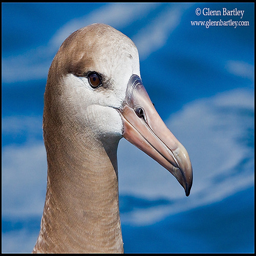

In [6]:
from PIL import Image

sample = dummy_dataset.data.iloc[0]
sample_path = CUB_DIR / 'images' / sample.filepath
print('Sample image:', sample_path)
display(Image.open(sample_path).convert('RGB').resize((256, 256)))

## 5. Run Baseline CLIP Image-to-Image Retrieval

The baseline uses standard CLIP features and disables IsoCLIP with `--no_iso`. Results are written to `results/kaggle_cub2011_clip_baseline/exp_*/summary.csv`.

The first run downloads the pretrained CLIP weights and extracts features. Features are cached under the project `data/image_features/...` directory.

Note that Kaggle sometimes assigns a Tesla P100 with `sm_60`, while some newer PyTorch images only build kernels for `sm_70+`. The cell below detects that case and runs retrieval on CPU to avoid the `no kernel image is available` error. To run faster on GPU, switch to a T4 or a PyTorch image compatible with P100 before rerunning.

In [7]:
def should_use_cpu_for_retrieval():
    if FORCE_CPU_RETRIEVAL:
        print('FORCE_CPU_RETRIEVAL=True, running retrieval on CPU')
        return True
    if not AUTO_CPU_FALLBACK_FOR_INCOMPATIBLE_GPU:
        return False
    try:
        import torch
        if not torch.cuda.is_available():
            print('CUDA is not available, retrieval.py will run on CPU')
            return False
        gpu_name = torch.cuda.get_device_name(0)
        capability = torch.cuda.get_device_capability(0)
        arch = f'sm_{capability[0]}{capability[1]}'
        arch_list = torch.cuda.get_arch_list()
        print('Detected GPU:', gpu_name, 'capability:', capability, 'required arch:', arch)
        print('PyTorch CUDA arch list:', arch_list)
        if arch not in arch_list:
            print(f'GPU arch {arch} is not supported by this PyTorch build. Running retrieval.py on CPU.')
            return True
        return False
    except Exception as exc:
        print('Could not validate CUDA compatibility:', repr(exc))
        print('Running retrieval.py on CPU to avoid CUDA kernel-image errors.')
        return True

def run_retrieval(out_path, no_iso=False):
    cmd = [
        sys.executable,
        str(PROJECT_DIR / 'src' / 'retrieval.py'),
        '--dataroot', str(DATA_ROOT),
        '--dataset_name', DATASET_NAME,
        '--clip_model_name', CLIP_MODEL_NAME,
        '--query_eval_type', 'image',
        '--gallery_eval_type', 'image',
        '--query_split', 'all',
        '--gallery_split', 'all',
        '--iso_ktop', str(ISO_KTOP),
        '--iso_kbottom', str(ISO_KBOTTOM),
        '--out_path', out_path,
    ]
    if no_iso:
        cmd.append('--no_iso')

    env = os.environ.copy()
    if should_use_cpu_for_retrieval():
        env['CUDA_VISIBLE_DEVICES'] = ''
    run(cmd, cwd=PROJECT_DIR, env=env)

if RUN_BASELINE:
    run_retrieval('kaggle_cub2011_clip_baseline', no_iso=True)
else:
    print('RUN_BASELINE=False, skip baseline run')

Detected GPU: Tesla T4 capability: (7, 5) required arch: sm_75
PyTorch CUDA arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
> /usr/bin/python3 /kaggle/working/IsoCLIP_ImageRetrieval/src/retrieval.py --dataroot /kaggle/working/datasets --dataset_name cub2011 --clip_model_name ViT-B/32 --query_eval_type image --gallery_eval_type image --query_split all --gallery_split all --iso_ktop 150 --iso_kbottom 50 --out_path kaggle_cub2011_clip_baseline --no_iso
Loading OpenAI CLIP model:  ViT-B/32


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 261MiB/s]


No ISO projection applied
Loading OpenAI CLIP model:  ViT-B/32

Extracting Gallery
Extracting features for cub2011 - all - ViT-B/32
Loading OpenAI CLIP model:  ViT-B/32


Extracting image features: 100%|██████████| 369/369 [00:39<00:00,  9.34it/s]



Extracting Queries
Features already extracted for cub2011 - all - ViT-B/32
Standard zero-shot retrieval without ISO projection


Computing retrieval metrics: 100%|██████████| 11788/11788 [00:18<00:00, 630.98it/s]





clip_model_name = ViT-B/32
dataset = cub2011
query_eval_type = image
gallery_eval_type = image
query_split = all
gallery_split = all
use_open_clip = False
open_clip_pretrained = None



cub2011_mAP = 22.92
cub2011_mAP_at_R = 15.53
cub2011_precision_at_R = 26.26
cub2011_recall_at_1 = 57.37
kaggle_cub2011_clip_baseline

✅ Summary saved at: results/kaggle_cub2011_clip_baseline/exp_20260503_172617_77h69/summary.csv



## 6. Run IsoCLIP Image-to-Image Retrieval

IsoCLIP uses the same dataset and model, but it uses pre-projection image features. The IsoCLIP projector is built from the SVD of the inter-modal operator `Psi = W_image.T @ W_text`, then removes the `ISO_KTOP` largest singular directions and the `ISO_KBOTTOM` smallest singular directions.

For `ViT-B/32`, the original project script uses `ISO_KTOP=150` and `ISO_KBOTTOM=50`.

In [8]:
if RUN_ISOCLIP:
    run_retrieval('kaggle_cub2011_isoclip', no_iso=False)
else:
    print('RUN_ISOCLIP=False, skip IsoCLIP run')

Detected GPU: Tesla T4 capability: (7, 5) required arch: sm_75
PyTorch CUDA arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
> /usr/bin/python3 /kaggle/working/IsoCLIP_ImageRetrieval/src/retrieval.py --dataroot /kaggle/working/datasets --dataset_name cub2011 --clip_model_name ViT-B/32 --query_eval_type image --gallery_eval_type image --query_split all --gallery_split all --iso_ktop 150 --iso_kbottom 50 --out_path kaggle_cub2011_isoclip
Loading OpenAI CLIP model:  ViT-B/32
ISO Top K = 150, ISO Bottom K = 50
Loading OpenAI CLIP model:  ViT-B/32

Extracting Gallery
Extracting image features without projection for ISO retrieval
Extracting features for cub2011 - all - ViT-B/32
Loading OpenAI CLIP model:  ViT-B/32


Extracting image features: 100%|██████████| 369/369 [00:38<00:00,  9.54it/s]



Extracting Queries
Extracting image features without projection for ISO retrieval
Features already extracted for cub2011 - all - ViT-B/32
Manual filtering: k_top = 150, k_bottom = 50


Computing retrieval metrics: 100%|██████████| 11788/11788 [00:17<00:00, 685.94it/s]





clip_model_name = ViT-B/32
dataset = cub2011
query_eval_type = image
gallery_eval_type = image
query_split = all
gallery_split = all
use_open_clip = False
open_clip_pretrained = None



cub2011_mAP = 27.03
cub2011_mAP_at_R = 18.71
cub2011_precision_at_R = 29.74
cub2011_recall_at_1 = 60.99
kaggle_cub2011_isoclip

✅ Summary saved at: results/kaggle_cub2011_isoclip/exp_20260503_172820_6vxkk/summary.csv



## 7. Inspect the IsoCLIP Projection in Code

This cell is not required for computing metrics, but it shows the core pipeline step: load the image/text projectors, build the IsoCLIP projectors, and inspect the retained subspace dimensionality.

In [9]:
import torch

from utils import load_clip
from encode_no_projection import get_projection_layers
from retrieval import apply_iso

def safe_torch_device():
    if FORCE_CPU_RETRIEVAL:
        return torch.device('cpu')
    try:
        if torch.cuda.is_available():
            capability = torch.cuda.get_device_capability(0)
            arch = f'sm_{capability[0]}{capability[1]}'
            if arch in torch.cuda.get_arch_list():
                return torch.device('cuda')
            print(f'Using CPU in this cell because GPU arch {arch} is unsupported by the current PyTorch build.')
    except Exception as exc:
        print('CUDA compatibility check failed, using CPU:', repr(exc))
    return torch.device('cpu')

device = safe_torch_device()
print('Device for projector inspection:', device)
clip_model, normalized_model_name, _ = load_clip(CLIP_MODEL_NAME, None, False, device)
W_image, W_text = get_projection_layers(clip_model, normalized_model_name)

W_image_for_iso = W_image.T
W_text_for_iso = W_text.T
W_text_iso, W_image_iso = apply_iso(W_text_for_iso, W_image_for_iso, ISO_KTOP, ISO_KBOTTOM)

rank = min(W_image_for_iso.shape[1], W_text_for_iso.shape[1])
kept = rank - ISO_KTOP - ISO_KBOTTOM

print('Model:', normalized_model_name)
print('W_image:', tuple(W_image.shape))
print('W_text:', tuple(W_text.shape))
print('W_image_iso:', tuple(W_image_iso.shape))
print('W_text_iso:', tuple(W_text_iso.shape))
print('Retained singular directions:', kept, '/', rank)

Device for projector inspection: cuda
Loading OpenAI CLIP model:  ViT-B/32
Manual filtering: k_top = 150, k_bottom = 50
Model: ViT-B/32
W_image: (768, 512)
W_text: (512, 512)
W_image_iso: (768, 512)
W_text_iso: (512, 512)
Retained singular directions: 312 / 512


## 8. Read Benchmark Results

The main retrieval metrics for CUB are:

- `mAP`: mean Average Precision.
- `mAP_at_R`: AP at R, where R is the number of relevant items for the query.
- `precision_at_R`: R-precision.
- `recall_at_1`: whether the top-1 result has the same class as the query.



In [10]:
import pandas as pd

summary_paths = sorted((PROJECT_DIR / 'results').glob('kaggle_cub2011_*/exp_*/summary.csv'))
print('Found summary files:', len(summary_paths))
for path in summary_paths:
    print(path)

assert summary_paths, 'No summary.csv found. Run the retrieval cells first.'

summary_df = pd.concat([pd.read_csv(path).assign(source_file=str(path)) for path in summary_paths], ignore_index=True)
columns = [
    'dataset_name',
    'clip_model_name',
    'no_iso',
    'iso_ktop',
    'iso_kbottom',
    'mAP',
    'mAP_at_R',
    'precision_at_R',
    'recall_at_1',
    'timestamp',
    'folder_path',
]
columns = [col for col in columns if col in summary_df.columns]

sort_cols = [col for col in ['no_iso', 'timestamp'] if col in summary_df.columns]
if not sort_cols:
    sort_cols = [columns[0]] if columns else []

display_df = summary_df.sort_values(sort_cols).reset_index(drop=True) if sort_cols else summary_df
display(display_df[columns])

Found summary files: 2
/kaggle/working/IsoCLIP_ImageRetrieval/results/kaggle_cub2011_clip_baseline/exp_20260503_172617_77h69/summary.csv
/kaggle/working/IsoCLIP_ImageRetrieval/results/kaggle_cub2011_isoclip/exp_20260503_172820_6vxkk/summary.csv


,dataset_name,clip_model_name,no_iso,iso_ktop,iso_kbottom,mAP,mAP_at_R,precision_at_R,recall_at_1,timestamp,folder_path
0,cub2011,ViT-B/32,False,150,50,27.028741,18.707641,29.737640,60.985748,20260503_172820,/kaggle/working/IsoCLIP_ImageRetrieval/results...
1,cub2011,ViT-B/32,True,-1,-1,22.917134,15.532724,26.264897,57.371904,20260503_172617,/kaggle/working/IsoCLIP_ImageRetrieval/results...
